# NSF FMRG Data Challenge — Participant Guide Notebook

This notebook is a starter guide for participants. It demonstrates how to:
1. load the thermal image sequence for a track,
2. inspect a thermal frame,
3. load an SEM tile,
4. load a Bruker/Wyko ASCII height map in physical units, and
5. optionally inspect a **display-only tilt correction** for selected tracks.

The examples are intentionally simple and are meant to be adapted.


In [19]:
# !pip install scipy

In [ ]:
# Google Colab setup
from pathlib import Path
from datetime import datetime
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from PIL import Image, ImageOps
import sys
import scipy

# Auto-detect repo root (works from notebooks/ on any machine: Mac, Linux, etc.)
# Auto-detect repo root: search upward from cwd for pyproject.toml -- robust to
# whatever directory Jupyter was launched from (local VS Code, remote Linux server, etc.)
def _find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return p  # fallback: no marker found, use cwd as-is

PROJECT_DIR = _find_repo_root()
print('PROJECT_DIR =', PROJECT_DIR)

# Add repo src utilities.
repo_src = PROJECT_DIR / 'src'
if str(repo_src) not in sys.path:
    sys.path.append(str(repo_src))

from nsf_fmrg_data import (
    extract_final_thermal_frames,
    get_sem_tile_paths,
    load_sem_tile,
    load_wyko_asc,
    robust_plane_detrend,
    display_shear_grid,
)

TRACK_IDS = [8, 10, 14, 21]
THERMAL_CMAP = 'jet'
THERMAL_VMIN = 1000.0
THERMAL_VMAX = 2500.0
HEIGHT_CMAP = 'jet'
HEIGHTMAP_RANGES_UM = {8: (-50, 125), 10: (-45, 110), 14: (-45, 70), 21: (-30, 45)}
THERMAL_PIXEL_SIZE_MM = 0.014  # 14 µm/pixel
SEM_TILE_WIDTH_MM = 6.41
SELECTED_SLOPE_EFF = {10: 0.003562, 14: -0.002517, 21: -0.002448}
SELECTED_STRENGTH = {10: 1.00, 14: 0.75, 21: 1.00}

RAW_DIR = PROJECT_DIR / 'data' / 'raw'
THERMAL_DIR = RAW_DIR / 'thermal'
SEM_DIR = RAW_DIR / 'sem'
HEIGHT_DIR = RAW_DIR / 'height_maps'

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = PROJECT_DIR / 'processed_data' / 'run_outputs' / RUN_TAG
FIGURES_DIR = RUN_DIR / 'figures'
VIDEOS_DIR = RUN_DIR / 'videos'
THERMAL_SAVE_DIR = RUN_DIR / 'thermal_frames'
METADATA_DIR = RUN_DIR / 'metadata'
PAPER_FIG_DIR = RUN_DIR / 'paper_figures'
for p in [RUN_DIR, FIGURES_DIR, VIDEOS_DIR, THERMAL_SAVE_DIR, METADATA_DIR, PAPER_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)
print('RUN_DIR =', RUN_DIR)


## 1. Load one thermal track


In [6]:
track_id = 8
thermal = extract_final_thermal_frames(THERMAL_DIR, track_id)
print('Thermal file:', thermal['file'])
print('Raw thermal shape:', thermal['raw_frames'].shape)
print('Extracted thermal shape:', thermal['frames'].shape)
print('First/last physical x (mm):', thermal['x_mm_center'][0], thermal['x_mm_center'][-1])


Thermal file: /Users/C.Y./nsf-fmrg-data-challenge/data/raw/thermal/Thermal_8.mat
Raw thermal shape: (929, 400, 400)
Extracted thermal shape: (400, 400, 400)
First/last physical x (mm): 20.099999999999994 99.9


## 2. Visualize a thermal frame in physical units


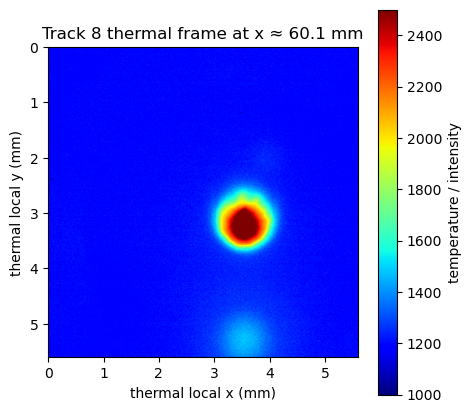

In [22]:
mid = len(thermal['frames']) // 2
thermal_img = thermal['frames'][mid]
thermal_extent = [0,
                  thermal_img.shape[1] * THERMAL_PIXEL_SIZE_MM,
                  thermal_img.shape[0] * THERMAL_PIXEL_SIZE_MM,
                  0]
plt.figure(figsize=(5, 5))
plt.imshow(thermal_img, cmap=THERMAL_CMAP, vmin=THERMAL_VMIN, vmax=THERMAL_VMAX, extent=thermal_extent)
plt.title(f'Track {track_id} thermal frame at x ≈ {thermal["x_mm_center"][mid]:.1f} mm')
plt.xlabel('thermal local x (mm)')
plt.ylabel('thermal local y (mm)')
cb = plt.colorbar()
cb.set_label('temperature / intensity')
plt.show()


## 3. Load one SEM tile (no stitching)


Number of SEM tiles: 13


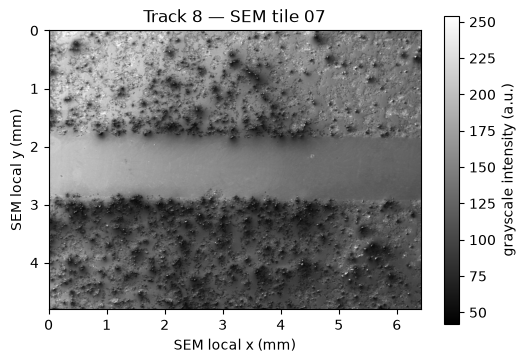

In [7]:
sem_tiles = get_sem_tile_paths(SEM_DIR, track_id)
print('Number of SEM tiles:', len(sem_tiles))
sem_img = load_sem_tile(sem_tiles[6])  # 7th tile if available
sem_h, sem_w = sem_img.shape
sem_height_mm = SEM_TILE_WIDTH_MM * sem_h / sem_w
plt.figure(figsize=(6, 4))
plt.imshow(sem_img, cmap='gray', extent=[0, SEM_TILE_WIDTH_MM, sem_height_mm, 0])
plt.title(f'Track {track_id} — SEM tile 07')
plt.xlabel('SEM local x (mm)')
plt.ylabel('SEM local y (mm)')
cb = plt.colorbar()
cb.set_label('grayscale intensity (a.u.)')
plt.show()


## 4. Load one Bruker/Wyko height map


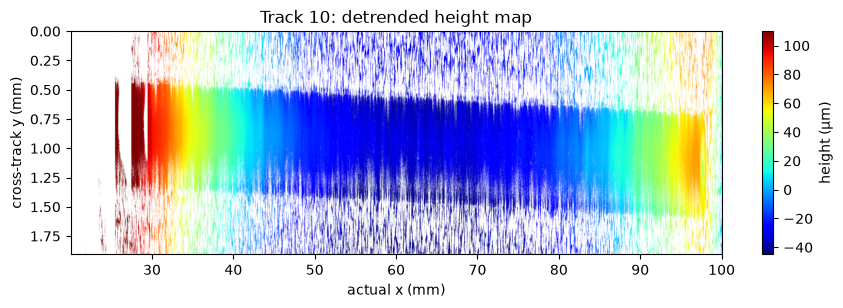

In [9]:
track_id = 10
height = load_wyko_asc(HEIGHT_DIR, track_id, crop_to_common=True)
Z_detrended, coef = robust_plane_detrend(height['Z_mm'], height['x_actual_mm'], height['y_mm'])
vmin_um, vmax_um = HEIGHTMAP_RANGES_UM[track_id]
plt.figure(figsize=(10.5, 2.9))
plt.imshow(Z_detrended * 1000.0, cmap=HEIGHT_CMAP, aspect='auto',
           extent=[float(height['x_actual_mm'][0]), float(height['x_actual_mm'][-1]), float(height['y_mm'][-1]), float(height['y_mm'][0])],
           vmin=vmin_um, vmax=vmax_um)
plt.title(f'Track {track_id}: detrended height map')
plt.xlabel('actual x (mm)')
plt.ylabel('cross-track y (mm)')
cb = plt.colorbar()
cb.set_label('height (µm)')
plt.show()


Array shape: (480, 20091)
Finite fraction: 0.4835543070695004
Finite values: 4663243


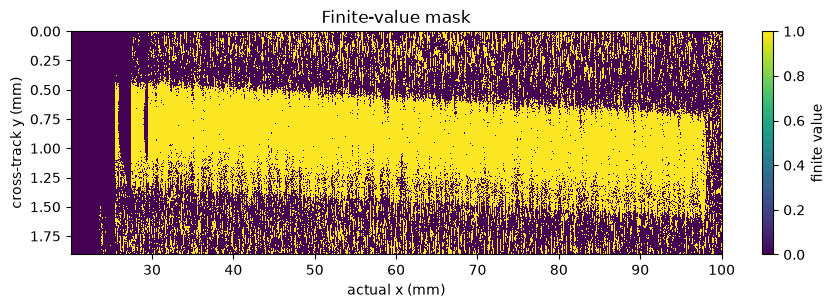

In [10]:
valid = np.isfinite(Z_detrended)

print("Array shape:", Z_detrended.shape)
print("Finite fraction:", valid.mean())
print("Finite values:", valid.sum())

plt.figure(figsize=(10.5, 2.9))
plt.imshow(
    valid,
    aspect="auto",
    interpolation="nearest",
    extent=[
        float(height["x_actual_mm"][0]),
        float(height["x_actual_mm"][-1]),
        float(height["y_mm"][-1]),
        float(height["y_mm"][0]),
    ],
)
plt.title("Finite-value mask")
plt.xlabel("actual x (mm)")
plt.ylabel("cross-track y (mm)")
plt.colorbar(label="finite value")
plt.show()

## 5. Optional: display-only tilt correction example


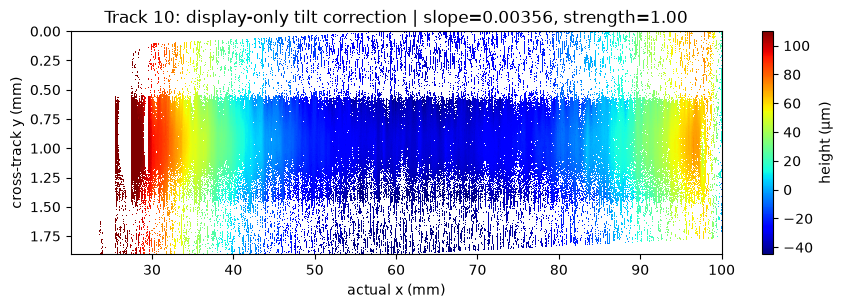

In [11]:
# The display-only correction does not resample the height values.
# It only shears the plotted coordinate grid to visually flatten a slight tilt.

track_id = 10
height = load_wyko_asc(HEIGHT_DIR, track_id, crop_to_common=True)
Z_detrended, coef = robust_plane_detrend(height['Z_mm'], height['x_actual_mm'], height['y_mm'])
x = height['x_actual_mm']
y = height['y_mm']
slope_eff = SELECTED_SLOPE_EFF[track_id]
strength = SELECTED_STRENGTH[track_id]
X_plot, Y_plot, correction = display_shear_grid(x, y, slope_eff=slope_eff, strength=strength)
plt.figure(figsize=(10.5, 2.9))
plt.pcolormesh(X_plot, Y_plot, Z_detrended * 1000.0, cmap=HEIGHT_CMAP,
               vmin=HEIGHTMAP_RANGES_UM[track_id][0], vmax=HEIGHTMAP_RANGES_UM[track_id][1], shading='auto')
plt.ylim(float(y[-1]), float(y[0]))
plt.xlim(float(x[0]), float(x[-1]))
plt.title(f'Track {track_id}: display-only tilt correction | slope={slope_eff:.5f}, strength={strength:.2f}')
plt.xlabel('actual x (mm)')
plt.ylabel('cross-track y (mm)')
cb = plt.colorbar()
cb.set_label('height (µm)')
plt.show()


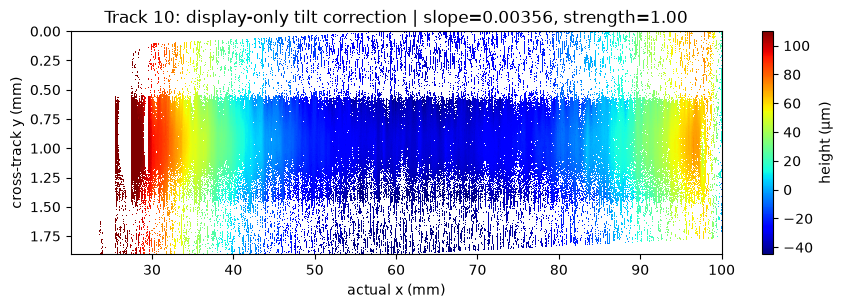

In [12]:
track_id = 10

height = load_wyko_asc(
    HEIGHT_DIR,
    track_id,
    crop_to_common=True,
)

Z_detrended, coef = robust_plane_detrend(
    height["Z_mm"],
    height["x_actual_mm"],
    height["y_mm"],
)

x = np.asarray(height["x_actual_mm"])
y = np.asarray(height["y_mm"])

slope_eff = SELECTED_SLOPE_EFF[track_id]
strength = SELECTED_STRENGTH[track_id]

X_plot, Y_plot, correction = display_shear_grid(
    x,
    y,
    slope_eff=slope_eff,
    strength=strength,
)

# Preserve the original Wyko validity mask
valid = np.isfinite(height["Z_mm"]) & np.isfinite(Z_detrended)

Z_plot_um = np.ma.array(
    Z_detrended * 1000.0,
    mask=~valid,
)

cmap = plt.get_cmap(HEIGHT_CMAP).copy()
cmap.set_bad("white", alpha=0.0)

fig, ax = plt.subplots(figsize=(10.5, 2.9))

pcm = ax.pcolormesh(
    X_plot,
    Y_plot,
    Z_plot_um,
    cmap=cmap,
    vmin=HEIGHTMAP_RANGES_UM[track_id][0],
    vmax=HEIGHTMAP_RANGES_UM[track_id][1],
    shading="nearest",
    edgecolors="none",
    antialiased=False,
    rasterized=True,
)

ax.set_ylim(float(y[-1]), float(y[0]))
ax.set_xlim(float(x[0]), float(x[-1]))

ax.set_title(
    f"Track {track_id}: display-only tilt correction | "
    f"slope={slope_eff:.5f}, strength={strength:.2f}"
)
ax.set_xlabel("actual x (mm)")
ax.set_ylabel("cross-track y (mm)")

cb = fig.colorbar(pcm, ax=ax)
cb.set_label("height (µm)")

plt.show()